In [2]:
import torch
from diffusers import DDPMPipeline
# from genaibook.core import get_device # Commented out as it's causing ModuleNotFoundError

# Set the device to use our GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use standard PyTorch to get the device

# Load the pipeline
image_pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipe.to(device)

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.39.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

In [7]:
# from genaibook.core import plot_noise_and_denoise # Commented out as 'genaibook' module is unavailable
# The random starting point is a batch of 4 images
# Each image is 3-channel (RGB) 256x256 pixel image
image = torch.randn(4, 3, 256, 256).to(device)
# Set the specific number of diffusion steps
image_pipe.scheduler.set_timesteps(num_inference_steps=30)
# Loop through the sampling timesteps
for i, t in enumerate(image_pipe.scheduler.timesteps):
  # Get the prediction given the current sample x and the timestep t
  # As we're running inference, we don't need to calculate gradients,
  # so we can use torch.inference_mode().
  with torch.inference_mode():
    # We need to pass in the timestep t so that the model knows what
    # timestep it's currently at. We'll learn more about this in the
    # coming sections.
    noise_pred = image_pipe.unet(image, t)["sample"]
  # Calculate what the updated x should look like with the scheduler
  scheduler_output = image_pipe.scheduler.step(noise_pred, t, image)
  # Update x
  image = scheduler_output.prev_sample
  # Occasionally display both x and the predicted denoised images
  if i % 10 == 0 or i == len(image_pipe.scheduler.timesteps) - 1:
    # plot_noise_and_denoise(scheduler_output, i) # Commented out as 'genaibook' module is unavailable
    pass # Added pass to ensure the if block is not empty and avoid 'incomplete input' syntax error

In [8]:
from datasets import load_dataset
dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  237MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [9]:
from torchvision import transforms
image_size = 64
# Define transformations
preprocess = transforms.Compose(
 [
 transforms.Resize((image_size, image_size)), # Resize
 transforms.RandomHorizontalFlip(), # Randomly flip (data augmentation)
 transforms.ToTensor(), # Convert to tensor (0, 1)
 transforms.Normalize([0.5], [0.5]), # Map to (-1, 1)
 ]
)

In [10]:
def transform(examples):
 examples = [preprocess(image) for image in examples["image"]]
 return {"images": examples}
dataset.set_transform(transform)
batch_size = 16
train_dataloader = torch.utils.data.DataLoader(
 dataset, batch_size=batch_size, shuffle=True
)

In [16]:
!pip install genaibook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


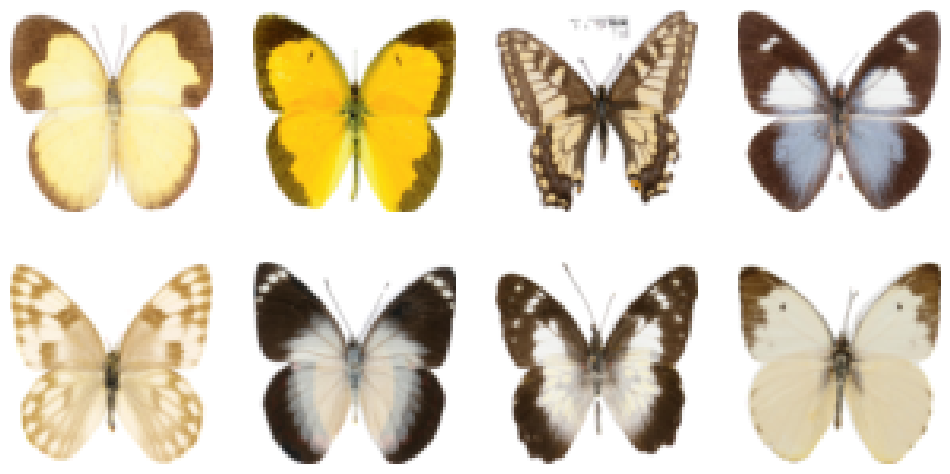

In [17]:
from genaibook.core import show_images # Commented out as 'genaibook' module is unavailable
batch = next(iter(train_dataloader))
# When we normalized, we mapped (0, 1) to (-1, 1)
# Now we map back to (0, 1) for display
show_images(batch["images"][:8] * 0.5 + 0.5) # Commented out as 'genaibook' module is unavailable

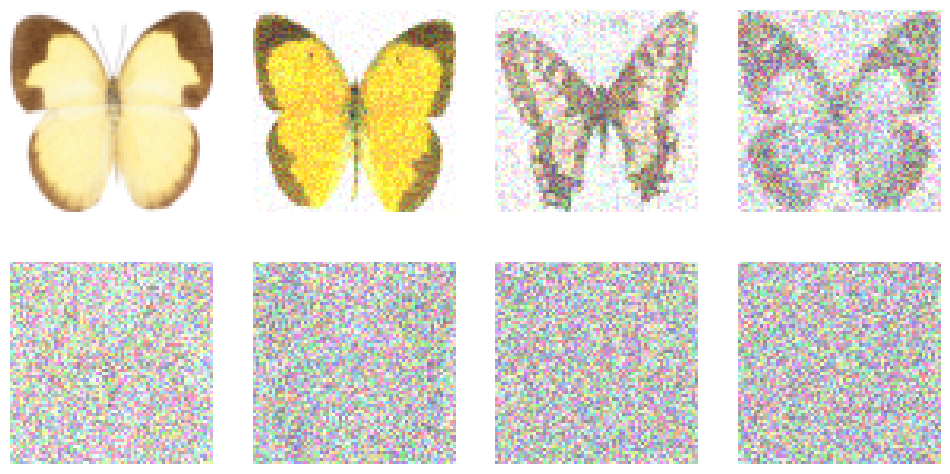

In [18]:
from diffusers import DDPMScheduler
# We'll learn about beta_start and beta_end in the next sections
scheduler = DDPMScheduler(
 num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)
# Create a tensor with 8 evenly spaced values from 0 to 999
timesteps = torch.linspace(0, 999, 8).long()
# We load 8 images from the dataset and
# add increasing amounts of noise to them
x = batch["images"][:8]
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))

In [19]:
from diffusers import UNet2DModel
model = UNet2DModel(
 in_channels=3, # 3 channels for RGB images
 sample_size=64, # Specify our input size
 # The number of channels per block affects the model size
 block_out_channels=(64, 128, 256, 512),
 down_block_types=(
 "DownBlock2D",
 "DownBlock2D",
 "AttnDownBlock2D",
 "AttnDownBlock2D",
 ),
 up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)
# Pass a batch of data through to make sure it works
with torch.inference_mode():
 out = model(noised_x.to(device), timestep=timesteps.to(device)).sample
print(noised_x.shape)
print(out.shape)


torch.Size([8, 3, 64, 64])
torch.Size([8, 3, 64, 64])


In [22]:
from torch.nn import functional as F
num_epochs = 50 # How many runs through the data should we do?
lr = 1e-4 # What learning rate should we use
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
losses = [] # Somewhere to store the loss values for later plotting
# Train the model (this takes a while)
for epoch in range(num_epochs):
  for batch in train_dataloader:
    # Load the input images
    clean_images = batch["images"].to(device)
    # Sample noise to add to the images
    noise = torch.randn(clean_images.shape).to(device)
    # Sample a random timestep for each image
    timesteps = torch.randint(
    0,
    scheduler.config.num_train_timesteps,
    (clean_images.shape[0],),
    device=device,
    ).long()
    # Add noise to the clean images according
    # to the noise magnitude at each timestep
    noisy_images = scheduler.add_noise(clean_images, noise, timesteps)
    # Get the model prediction for the noise
    # The model also uses the timestep as an input
    # for additional conditioning
    noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
    # Compare the prediction with the actual noise
    loss = F.mse_loss(noise_pred, noise)
    # Store the loss for later plotting
    losses.append(loss.item())
    # Update the model parameters with the optimizer based on this loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

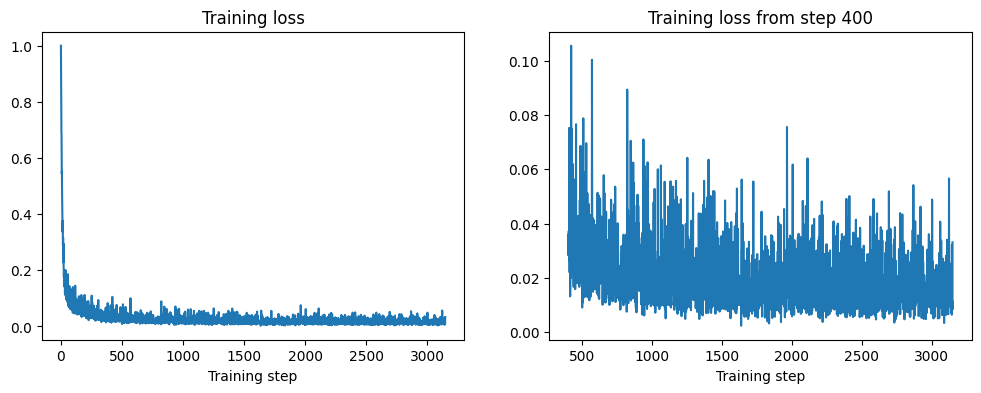

In [23]:
from matplotlib import pyplot as plt
plt.subplots(1, 2, figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Training loss")
plt.xlabel("Training step")
plt.subplot(1, 2, 2)
plt.plot(range(400, len(losses)), losses[400:])
plt.title("Training loss from step 400")
plt.xlabel("Training step");

  0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'DDPMPipeline' object attribute is deprecated. Please access '__iter__' over 'DDPMPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'UNet2DModel' object attribute is deprecated. Please access '__iter__' over 'UNet2DModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'DDPMScheduler' object attribute is deprecated. Please access '__iter__' over 'DDPMScheduler's config object instead, e.g

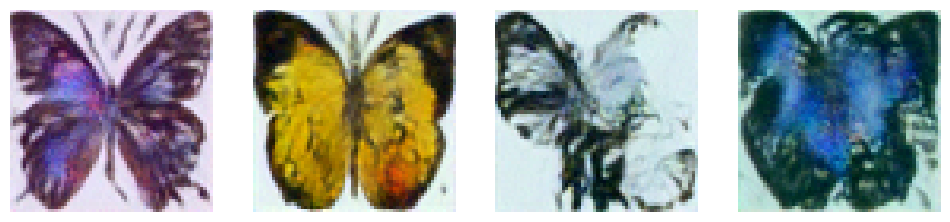

In [24]:
pipeline = DDPMPipeline(unet=model, scheduler=scheduler)
ims = pipeline(batch_size=4).images
show_images(ims, nrows=1)

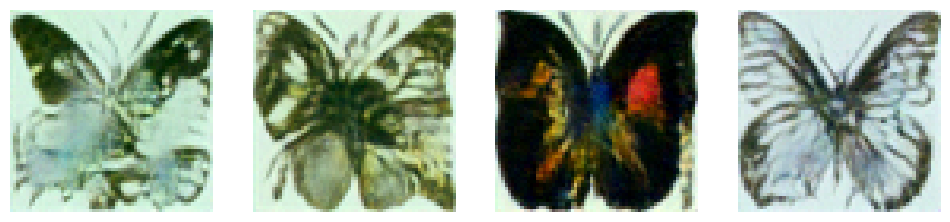

In [25]:
# Random starting point (4 random images):
sample = torch.randn(4, 3, 64, 64).to(device)
for t in scheduler.timesteps:
 # Get the model prediction
 with torch.inference_mode():
  noise_pred = model(sample, t)["sample"]
 # Update sample with step
 sample = scheduler.step(noise_pred, t, sample).prev_sample
show_images(sample.clip(-1, 1) * 0.5 + 0.5, nrows=1)

In [26]:
x = next(iter(train_dataloader))["images"][:8]
noise = torch.rand_like(x)

In [27]:
def corrupt(x, noise, amount):
 # Reshape amount so it works correctly with the original data
 amount = amount.view(-1, 1, 1, 1) # make sure it's broadcastable
 # Blend the original data and noise based on the amount
 return (
 x * (1 - amount) + noise * amount
 ) # equivalent to x.lerp(noise, amount)

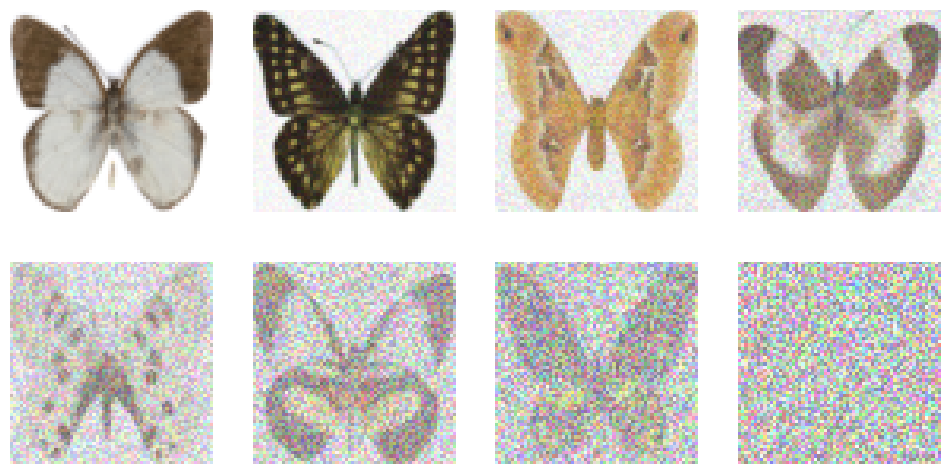

In [28]:
amount = torch.linspace(0, 1, 8)
noised_x = corrupt(x, noise, amount)
show_images(noised_x * 0.5 + 0.5)

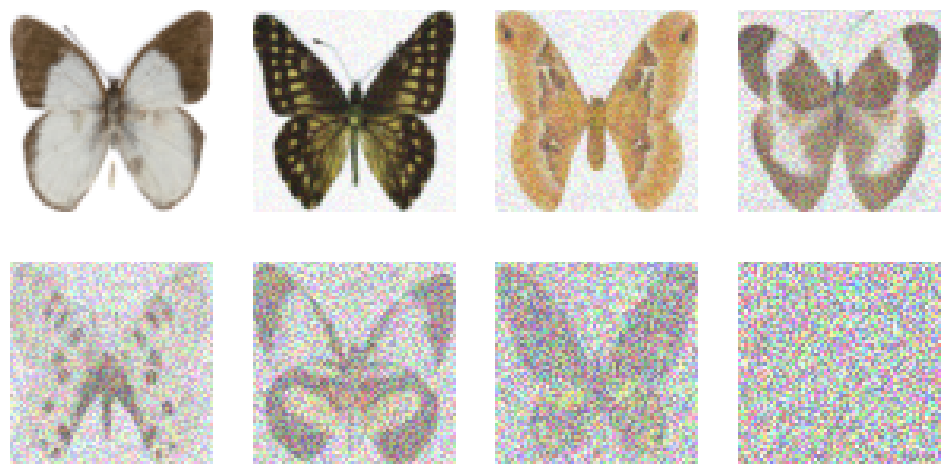

In [29]:
class SimpleScheduler:
 def __init__(self):
  self.num_train_timesteps = 1000
 def add_noise(self, x, noise, timesteps):
  amount = timesteps / self.num_train_timesteps
  return corrupt(x, noise, amount)

scheduler = SimpleScheduler()
timesteps = torch.linspace(0, 999, 8).long()
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images(noised_x * 0.5 + 0.5)


In [ ]:
scheduler = DDPMScheduler(beta_end=0.01)
timesteps = torch.linspace(0, 999, 8).long()
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))

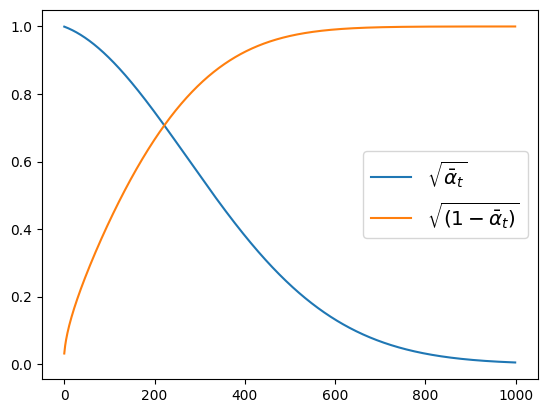

In [30]:
from genaibook.core import plot_scheduler
plot_scheduler(
 DDPMScheduler(beta_start=0.001, beta_end=0.02, beta_schedule="linear")
)


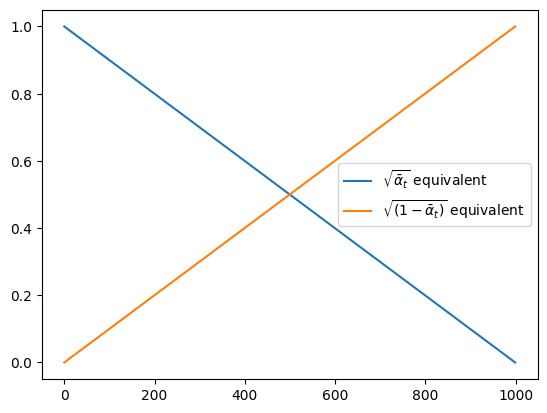

In [31]:
plot_scheduler(SimpleScheduler())

In [32]:
from torch import nn
class BasicUNet(nn.Module):
 """A minimal UNet implementation."""
 def __init__(self, in_channels=1, out_channels=1):
  super().__init__()
  self.down_layers = nn.ModuleList(
  [
  nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
  nn.Conv2d(32, 64, kernel_size=5, padding=2),
  nn.Conv2d(64, 64, kernel_size=5, padding=2),
  ]
  )
  self.up_layers = nn.ModuleList(
  [
  nn.Conv2d(64, 64, kernel_size=5, padding=2),
  nn.Conv2d(64, 32, kernel_size=5, padding=2),
  nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
  ]
  )
  # Use the SiLU activation function, which has been shown to work well
  # due to different properties (smoothness, non-monotonicity, etc.).
  self.act = nn.SiLU()
  self.downscale = nn.MaxPool2d(2)
  self.upscale = nn.Upsample(scale_factor=2)

 def forward(self, x):
  h = []
  for i, l in enumerate(self.down_layers):
    x = self.act(l(x))
    if i < 2: # For all but the third (final) down layer:
      h.append(x) # Storing output for skip connection
      x = self.downscale(x) # Downscale ready for the next layer
  for i, l in enumerate(self.up_layers):
    if i > 0: # For all except the first up layer
      x = self.upscale(x) # Upscale
      x += h.pop() # Fetching stored output (skip connection)
      x = self.act(l(x))
  return x